In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

df = pd.read_csv("database_gEEN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEEN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)

numeric_cols = ["coh","gEEN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,coh,gEIN,gEEN,gIE,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,6.4,0.13,0.165,1.3,2,1750.7,NaN,1750.7,30.931057,5.828264,2.4,2.4,A01
1,6.4,0.13,0.165,1.3,1,NaN,1538.9,1538.9,8.483916,27.834914,2.4,2.4,A02
2,6.4,0.13,0.165,1.3,2,1775.8,NaN,1775.8,28.160257,7.431875,2.4,2.4,A03
3,6.4,0.13,0.165,1.3,2,1646.9,NaN,1646.9,33.118578,5.491497,2.4,2.4,A04
4,6.4,0.13,0.165,1.3,2,1778.7,NaN,1778.7,30.506251,7.847450,2.4,2.4,A05


In [9]:
# Automatically detect gEEN values
gEEN_values = sorted(df["gEEN"].dropna().unique())

# Create a perceptually uniform color palette (no overlapping colors)
import numpy as np
import matplotlib.pyplot as plt

palette = plt.cm.viridis(np.linspace(0, 1, len(gEEN_values)))
gEEN_color_map = dict(zip(gEEN_values, palette))

gEEN_color_map


{np.float64(0.15675): array([0.267004, 0.004874, 0.329415, 1.      ]),
 np.float64(0.1584): array([0.253935, 0.265254, 0.529983, 1.      ]),
 np.float64(0.16005): array([0.163625, 0.471133, 0.558148, 1.      ]),
 np.float64(0.1617): array([0.134692, 0.658636, 0.517649, 1.      ]),
 np.float64(0.16335): array([0.477504, 0.821444, 0.318195, 1.      ]),
 np.float64(0.165): array([0.993248, 0.906157, 0.143936, 1.      ])}

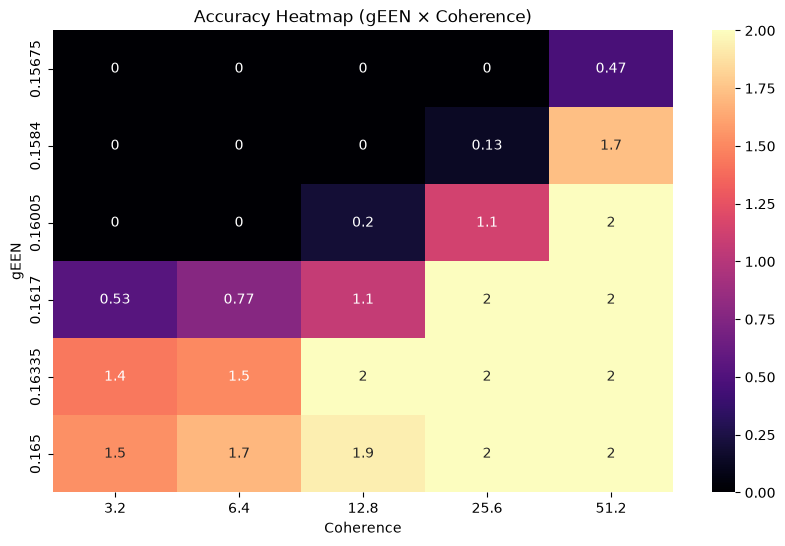

In [10]:
pivot = df.pivot_table(values="acc", index="gEEN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEEN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEEN")
plt.show()


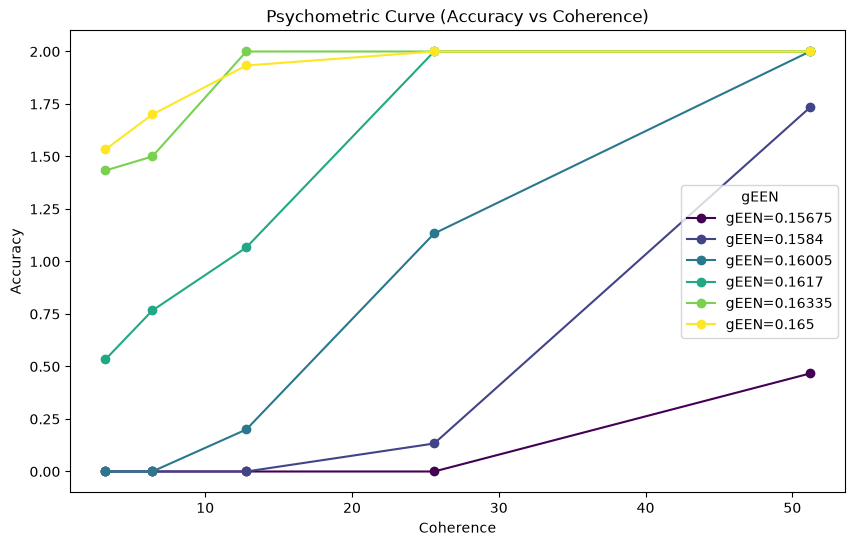

In [11]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["acc"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Accuracy")
plt.title("Psychometric Curve (Accuracy vs Coherence)")
plt.legend(title="gEEN")
plt.grid(False)
plt.show()


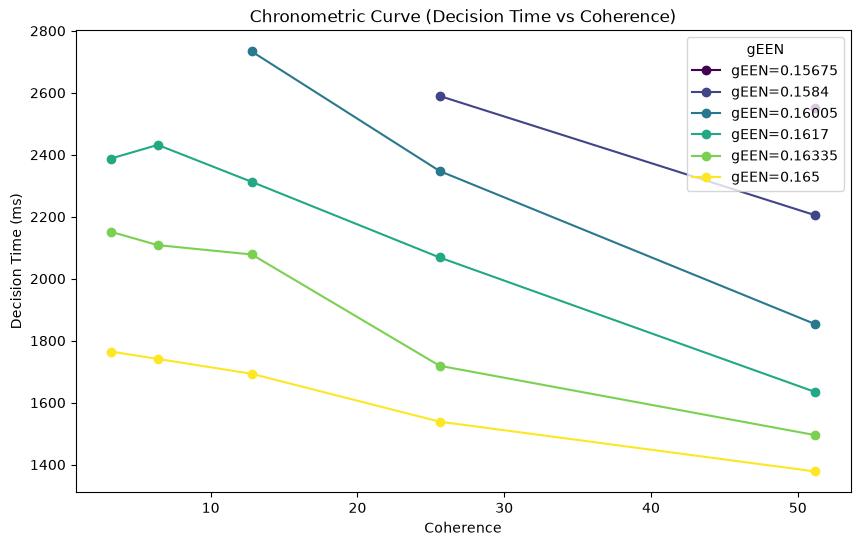

In [12]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["dt"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Decision Time (ms)")
plt.title("Chronometric Curve (Decision Time vs Coherence)")
plt.legend(title="gEEN")
plt.grid(False)
plt.show()


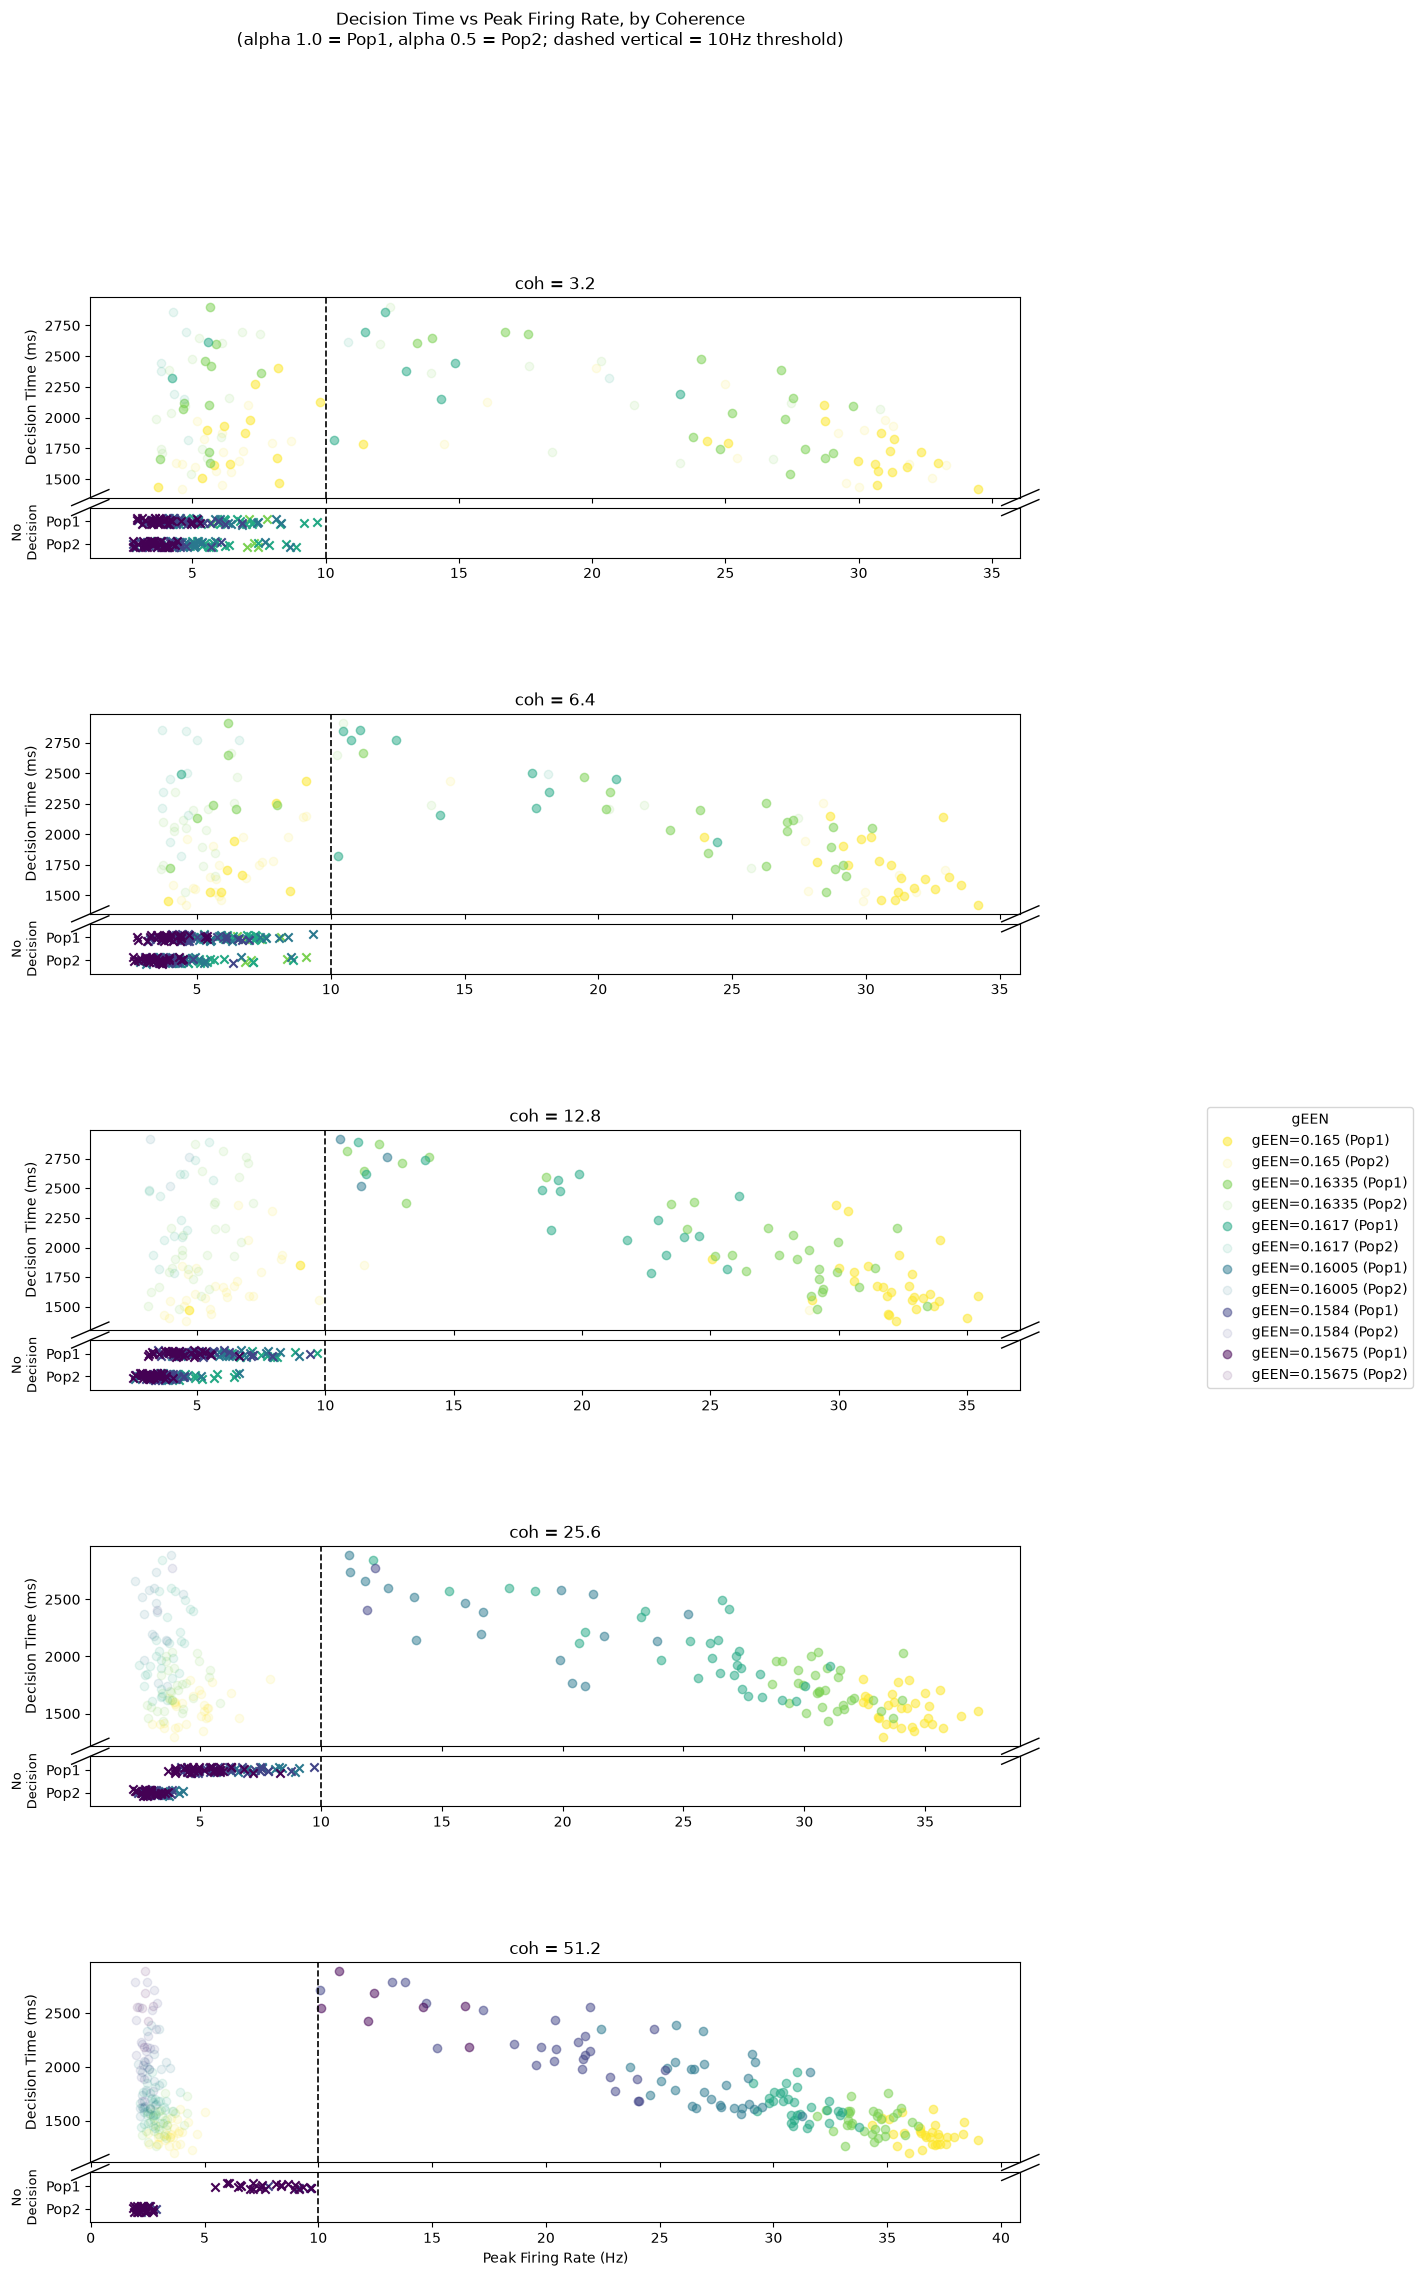

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_plot = df.copy()
coh_levels = sorted(df_plot["coh"].unique())
n_panels = len(coh_levels)

fig = plt.figure(figsize=(12, 5 * n_panels))
outer_gs = gridspec.GridSpec(n_panels, 1, hspace=0.6, figure=fig)

for i, coh in enumerate(coh_levels):
    # Each coherence group gets its own mini grid: big axis (dt) + thin axis (no-decision)
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[i], height_ratios=[4, 1], hspace=0.08
    )
    ax_main = fig.add_subplot(inner_gs[0])
    ax_nodec = fig.add_subplot(inner_gs[1], sharex=ax_main)

    panel_data = df_plot[df_plot["coh"] == coh]

    for gEEN in panel_data["gEEN"].unique():
        subset = panel_data[panel_data["gEEN"] == gEEN]
        color = gEEN_color_map[gEEN]

        decided = subset[subset["acc"] != 0]
        no_dec = subset[subset["acc"] == 0]

        # Main axis: real decision times
        ax_main.scatter(decided["peak1"], decided["dt"], color=color, alpha=0.5, label=f"gEEN={gEEN} (Pop1)")
        ax_main.scatter(decided["peak2"], decided["dt"], color=color, alpha=0.1, label=f"gEEN={gEEN} (Pop2)")

        # No-decision axis: two tight rows, pop1 on top, pop2 below
        jitter_pop1 = 1 + np.random.uniform(-0.15, 0.15, size=len(no_dec))
        jitter_pop2 = 0 + np.random.uniform(-0.15, 0.15, size=len(no_dec))
        ax_nodec.scatter(no_dec["peak1"], jitter_pop1, color=color, alpha=1, marker="x")
        ax_nodec.scatter(no_dec["peak2"], jitter_pop2, color=color, alpha=1, marker="x")

    ax_main.axvline(10, color="black", linestyle="--", linewidth=1.2)
    ax_nodec.axvline(10, color="black", linestyle="--", linewidth=1.2)

    ax_nodec.set_ylim(-0.6, 1.6)
    ax_nodec.set_yticks([0, 1])
    ax_nodec.set_yticklabels(["Pop2", "Pop1"])
    ax_nodec.set_ylabel("No\nDecision", fontsize=9)

    ax_main.set_ylabel("Decision Time (ms)")
    ax_main.set_title(f"coh = {coh}")
    plt.setp(ax_main.get_xticklabels(), visible=False)  # hide since it duplicates ax_nodec's

    # Break marks between the two axes to visually signal the axis discontinuity
    d = 0.02
    kwargs = dict(transform=ax_main.transAxes, color='k', clip_on=False, linewidth=1)
    ax_main.plot((-d, +d), (-d*2, +d*2), **kwargs)
    ax_main.plot((1-d, 1+d), (-d*2, +d*2), **kwargs)
    kwargs.update(transform=ax_nodec.transAxes)
    ax_nodec.plot((-d, +d), (1-d*8, 1+d*8), **kwargs)
    ax_nodec.plot((1-d, 1+d), (1-d*8, 1+d*8), **kwargs)

ax_last = fig.axes[-1]
ax_last.set_xlabel("Peak Firing Rate (Hz)")
fig.suptitle(
    "Decision Time vs Peak Firing Rate, by Coherence\n"
    "(alpha 1.0 = Pop1, alpha 0.5 = Pop2; dashed vertical = 10Hz threshold)",
    y=0.995
)

handles, labels = fig.axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), title="gEEN", bbox_to_anchor=(1.05, 0.5), loc="center left")

#plt.tight_layout()
plt.show()

 coh    gEEN  Correct  Wrong  No Decision  Total  % Correct  % Wrong  % No Decision
 3.2 0.15675        0      0           30     30        0.0      0.0          100.0
 3.2 0.15840        0      0           30     30        0.0      0.0          100.0
 3.2 0.16005        0      0           30     30        0.0      0.0          100.0
 3.2 0.16170        7      2           21     30       23.3      6.7           70.0
 3.2 0.16335       16     11            3     30       53.3     36.7           10.0
 3.2 0.16500       16     14            0     30       53.3     46.7            0.0
 6.4 0.15675        0      0           30     30        0.0      0.0          100.0
 6.4 0.15840        0      0           30     30        0.0      0.0          100.0
 6.4 0.16005        0      0           30     30        0.0      0.0          100.0
 6.4 0.16170       11      1           18     30       36.7      3.3           60.0
 6.4 0.16335       19      7            4     30       63.3     23.3        

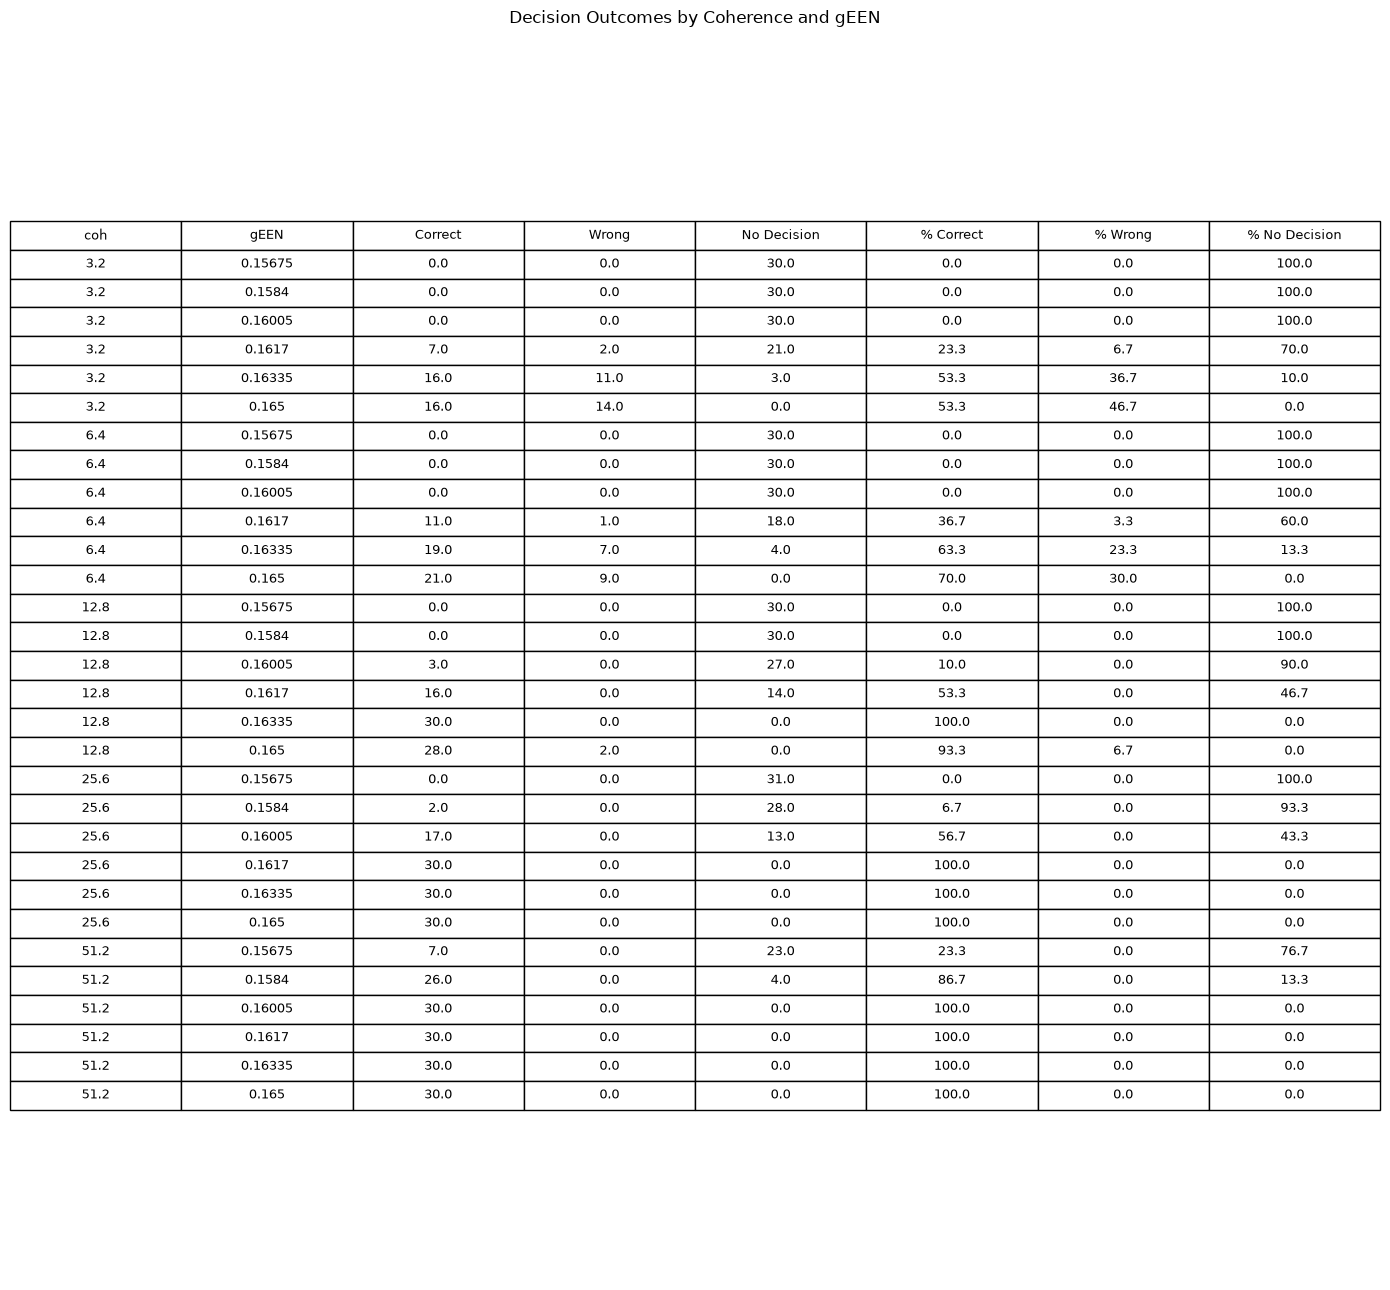

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df.copy()

# Build counts table: rows = (coh, gEEN), columns = outcome counts
acc_labels = {0: "No Decision", 1: "Wrong", 2: "Correct"}
df_plot["outcome"] = df_plot["acc"].map(acc_labels)

table = (
    df_plot
    .groupby(["coh", "gEEN", "outcome"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Correct", "Wrong", "No Decision"], fill_value=0)  # consistent column order
    .reset_index()
)

# Optional: add a total column and proportion columns for a fuller picture
table["Total"] = table[["Correct", "Wrong", "No Decision"]].sum(axis=1)
table["% Correct"] = (table["Correct"] / table["Total"] * 100).round(1)
table["% Wrong"] = (table["Wrong"] / table["Total"] * 100).round(1)
table["% No Decision"] = (table["No Decision"] / table["Total"] * 100).round(1)

print(table.to_string(index=False))

# ============================================================
# RENDER AS AN ACTUAL TABLE FIGURE (not just printed text)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 0.4 * len(table) + 1))
ax.axis("off")

display_cols = ["coh", "gEEN", "Correct", "Wrong", "No Decision", "% Correct", "% Wrong", "% No Decision"]
cell_text = table[display_cols].values

tbl = ax.table(
    cellText=cell_text,
    colLabels=display_cols,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)

plt.title("Decision Outcomes by Coherence and gEEN", pad=20)
plt.tight_layout()
plt.savefig("outcome_table.png", dpi=200, bbox_inches="tight")
plt.show()

In [32]:
no_dec = df[df["acc"] == 0].copy()
no_dec["margin"] = no_dec["peak1"] - no_dec["peak2"]

margin_stats = no_dec.groupby("coh")["margin"].agg(["mean", "std", "min", "max", "count"])
print(margin_stats)

          mean       std       min       max  count
coh                                                
3.2   0.439145  1.746887 -4.493700  4.374805    114
6.4   0.879037  1.604243 -4.256059  4.431966    112
12.8  1.761261  1.575830 -1.583711  5.409502    101
25.6  2.962990  1.486286  0.120352  7.122822     72
51.2  5.595341  1.315840  3.008676  7.687564     27


In [33]:
# ============================================================
# POINT 5: Does dt among CORRECT trials increase as gEEN decreases?
# ============================================================

correct_only = df[df["acc"] == 2].copy()

dt_by_geen_coh = (
    correct_only
    .groupby(["coh", "gEEN"])["dt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(dt_by_geen_coh.to_string(index=False))

 coh    gEEN        mean        std  count
 3.2 0.16170 2364.300000 350.413137      7
 3.2 0.16335 2127.156250 404.001170     16
 3.2 0.16500 1708.887500 182.388658     16
 6.4 0.16170 2426.290909 363.944698     11
 6.4 0.16335 2036.826316 290.384387     19
 6.4 0.16500 1722.619048 223.988135     21
12.8 0.16005 2733.400000 198.690387      3
12.8 0.16170 2312.625000 335.451945     16
12.8 0.16335 2078.220000 411.270210     30
12.8 0.16500 1695.350000 245.642466     28
25.6 0.15840 2589.900000 260.498138      2
25.6 0.16005 2347.594118 328.783606     17
25.6 0.16170 2068.566667 333.720971     30
25.6 0.16335 1719.013333 177.414124     30
25.6 0.16500 1538.620000 138.263463     30
51.2 0.15675 2551.100000 216.129776      7
51.2 0.15840 2204.773077 316.089332     26
51.2 0.16005 1853.233333 242.521225     30
51.2 0.16170 1634.203333 135.783587     30
51.2 0.16335 1495.183333 116.944349     30
51.2 0.16500 1377.810000  99.257451     30


    coh  threshold_gEEN  pct_decrease
0   3.2         0.16170           2.0
1   6.4         0.16170           2.0
2  12.8         0.16005           3.0
3  25.6         0.15840           4.0
4  51.2         0.15675           5.0


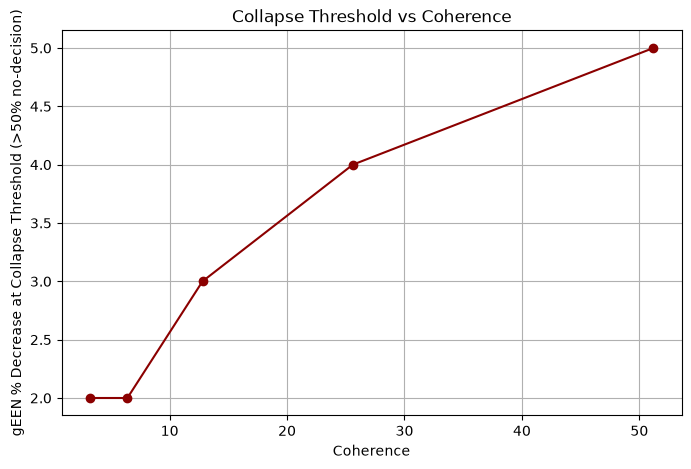

In [30]:
# ============================================================
# POINT 3: At what gEEN value does each coherence level "collapse"?
# Define collapse threshold as: gEEN value where % No Decision first exceeds 50%
# ============================================================

df_plot = df.copy()
df_plot["outcome"] = df_plot["acc"].map({0: "No Decision", 1: "Wrong", 2: "Correct"})

table = (
    df_plot
    .groupby(["coh", "gEEN", "outcome"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Correct", "Wrong", "No Decision"], fill_value=0)
    .reset_index()
)
table["Total"] = table[["Correct", "Wrong", "No Decision"]].sum(axis=1)
table["pct_no_decision"] = table["No Decision"] / table["Total"] * 100

thresholds = []
for coh in sorted(table["coh"].unique()):
    subset = table[table["coh"] == coh].sort_values("gEEN", ascending=False)  # highest gEEN (least reduction) first
    crossing = subset[subset["pct_no_decision"] > 50]
    if not crossing.empty:
        threshold_geen = crossing.iloc[0]["gEEN"]  # first gEEN value where it exceeds 50%
        pct_decrease = (0.165 - threshold_geen) / 0.165 * 100
        thresholds.append({"coh": coh, "threshold_gEEN": threshold_geen, "pct_decrease": pct_decrease})
    else:
        thresholds.append({"coh": coh, "threshold_gEEN": None, "pct_decrease": None})

threshold_df = pd.DataFrame(thresholds)
print(threshold_df)

# Plot: does the collapse threshold (% decrease) rise with coherence?
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["coh"], threshold_df["pct_decrease"], marker="o", color="darkred")
plt.xlabel("Coherence")
plt.ylabel("gEEN % Decrease at Collapse Threshold (>50% no-decision)")
plt.title("Collapse Threshold vs Coherence")
plt.grid(True)
plt.show()

coh           3.2        6.4         12.8   25.6   51.2
gEEN                                                   
0.15675        NaN        NaN         NaN    NaN  100.0
0.15840        NaN        NaN         NaN  100.0  100.0
0.16005        NaN        NaN  100.000000  100.0  100.0
0.16170  77.777778  91.666667  100.000000  100.0  100.0
0.16335  59.259259  73.076923  100.000000  100.0  100.0
0.16500  53.333333  70.000000   93.333333  100.0  100.0


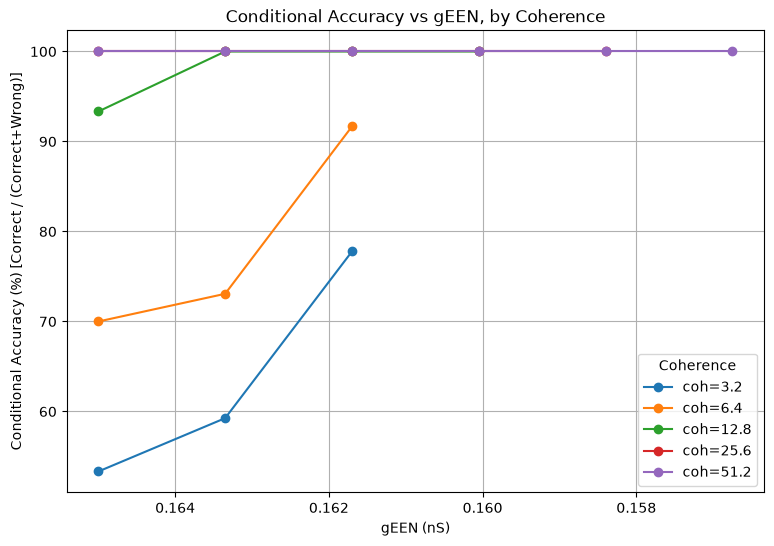

In [31]:
# ============================================================
# POINT 4: Does conditional accuracy (Correct / (Correct+Wrong)) 
# rise as gEEN decreases, at EVERY coherence level?
# ============================================================

table["decided"] = table["Correct"] + table["Wrong"]
table["conditional_accuracy"] = table.apply(
    lambda row: row["Correct"] / row["decided"] * 100 if row["decided"] > 0 else None,
    axis=1
)

pivot = table.pivot(index="gEEN", columns="coh", values="conditional_accuracy")
print(pivot)

plt.figure(figsize=(9, 6))
for coh in sorted(table["coh"].unique()):
    subset = table[table["coh"] == coh].sort_values("gEEN")
    plt.plot(subset["gEEN"], subset["conditional_accuracy"], marker="o", label=f"coh={coh}")

plt.gca().invert_xaxis()  # so gEEN decreasing (more hypofunction) reads left-to-right
plt.xlabel("gEEN (nS)")
plt.ylabel("Conditional Accuracy (%) [Correct / (Correct+Wrong)]")
plt.title("Conditional Accuracy vs gEEN, by Coherence")
plt.legend(title="Coherence")
plt.grid(True)
plt.show()